In [3]:
%pip install numpy pandas matplotlib seaborn mplfinance scipy scikit-learn
%pip install scikit-learn
%pip install numpy
%pip install pandas
%pip install matplotlib.pyplot
%pip install seaborn
%pip install mplfinance

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

In [5]:
# Load Dataset 
data = pd.read_csv("data_YesBank_StockPrices.csv")

In [6]:
# Dataset First Look
data.head(180)

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41
...,...,...,...,...,...
175,Feb-20,39.10,40.70,33.60,34.55
176,Mar-20,35.20,87.95,5.55,22.45
177,Apr-20,22.30,30.45,20.30,27.95
178,May-20,27.80,31.60,25.20,26.85


In [7]:
# Dataset Rows & Columns count
data.shape

(185, 5)

In [8]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


In [9]:
# Dataset Duplicate Value Count
data.duplicated().sum()

np.int64(0)

In [10]:
# Dataset Duplicate Value Count
data.duplicated().sum()

np.int64(0)

In [11]:
# Missing Values/Null Values Count
data.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

In [12]:
# Dataset Columns
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [13]:
# Dataset Describe
data.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


In [14]:
# Write your code to make your dataset analysis ready.

# Assuming 'date' column is already in datetime format, if not, convert it to datetime
data['Date'] = pd.to_datetime(data['Date'], format='%b-%y')

# Confirming data types
print(data.dtypes)

Date     datetime64[ns]
Open            float64
High            float64
Low             float64
Close           float64
dtype: object


In [15]:
df = data.copy()
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date').set_index('Date')
print("Period:", df.index.min().date(), "to", df.index.max().date())
df.head()

Period: 2005-07-01 to 2020-11-01


,Open,High,Low,Close
Date,,,,
2005-07-01,13.00,14.00,11.25,12.46
2005-08-01,12.58,14.88,12.55,13.42
2005-09-01,13.48,14.87,12.27,13.30
2005-10-01,13.20,14.47,12.40,12.99
2005-11-01,13.35,13.88,12.88,13.41


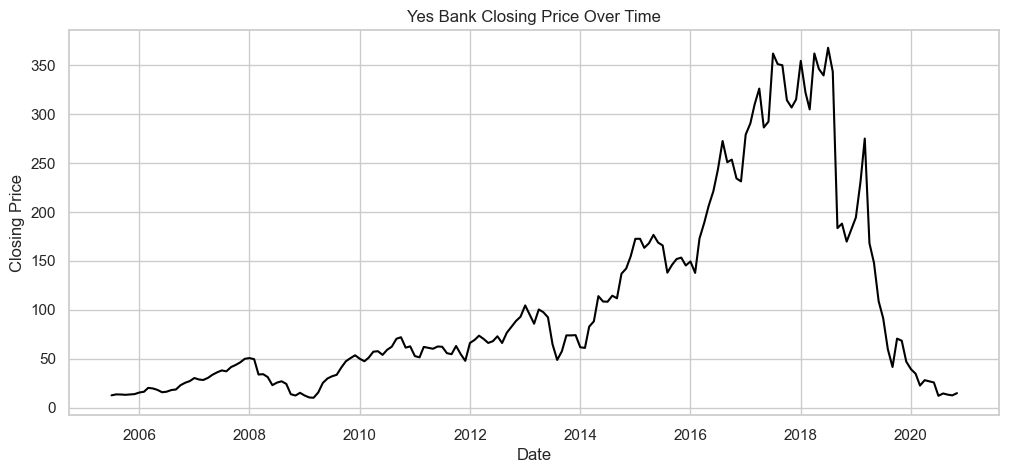

In [16]:
# Closing price over time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], color='black')
plt.title('Yes Bank Closing Price Over Time')
plt.xlabel('Date'); plt.ylabel('Closing Price')
plt.show()

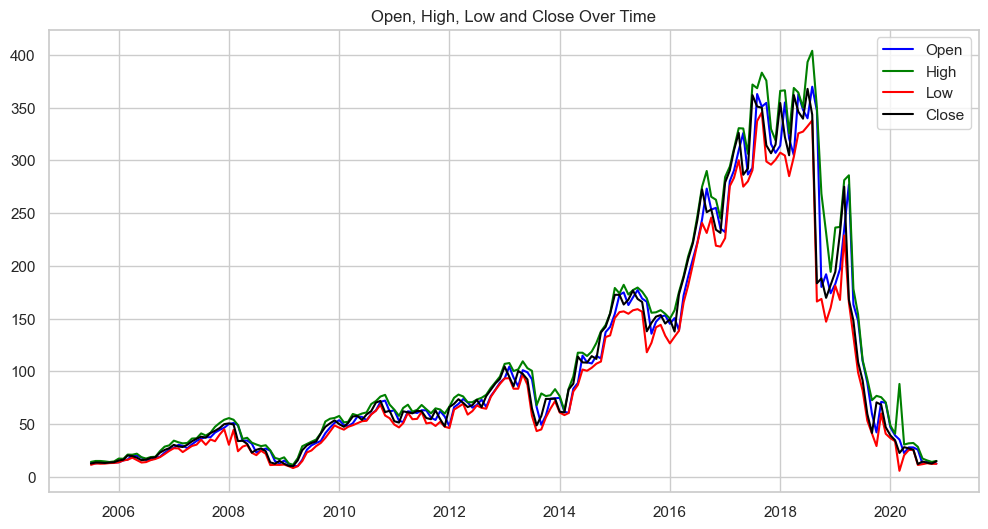

In [17]:
# Open, High, Low, Close together
plt.figure(figsize=(12, 6))
for col, color in [('Open', 'blue'), ('High', 'green'), ('Low', 'red'), ('Close', 'black')]:
    plt.plot(df.index, df[col], label=col, color=color)
plt.title('Open, High, Low and Close Over Time')
plt.legend()
plt.show()

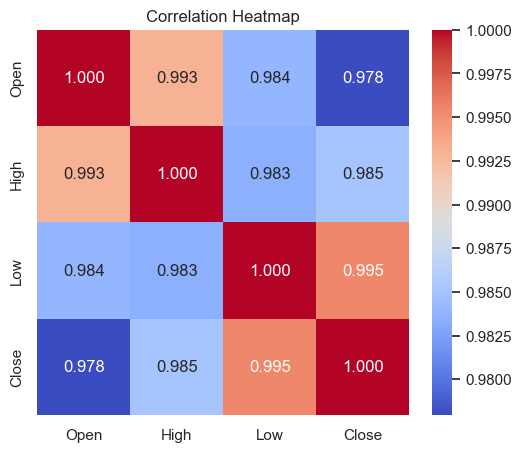

In [18]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Heatmap')
plt.show()


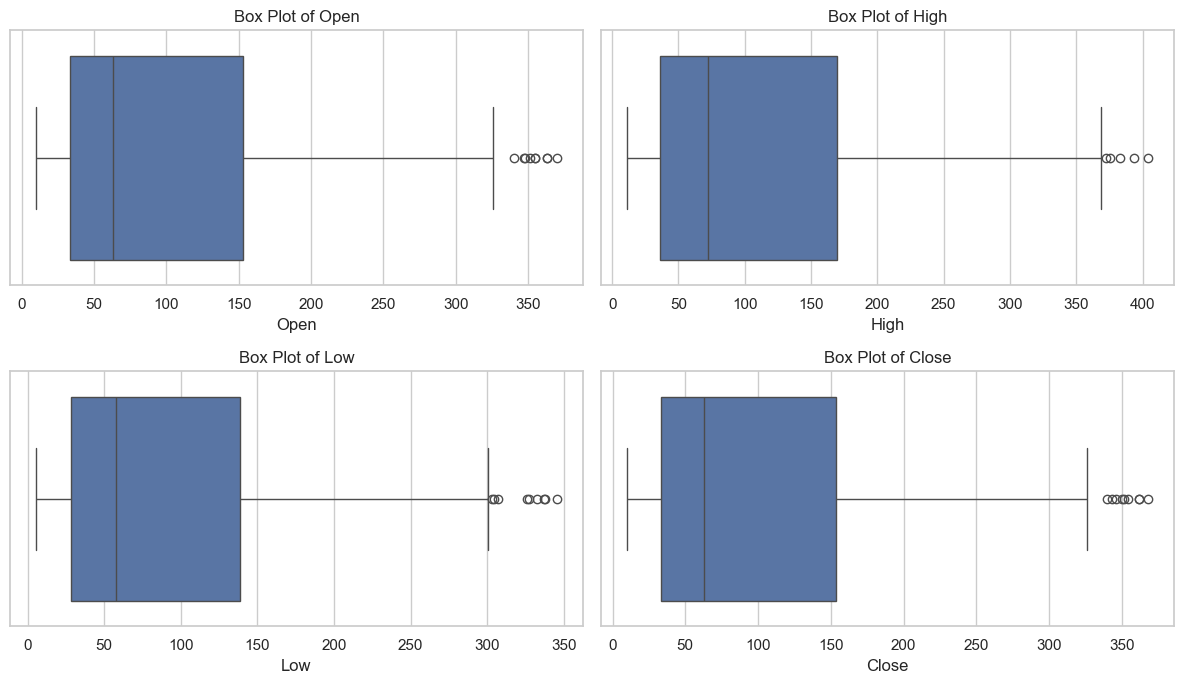

In [19]:
# Box plots
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.ravel(), ['Open', 'High', 'Low', 'Close']):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

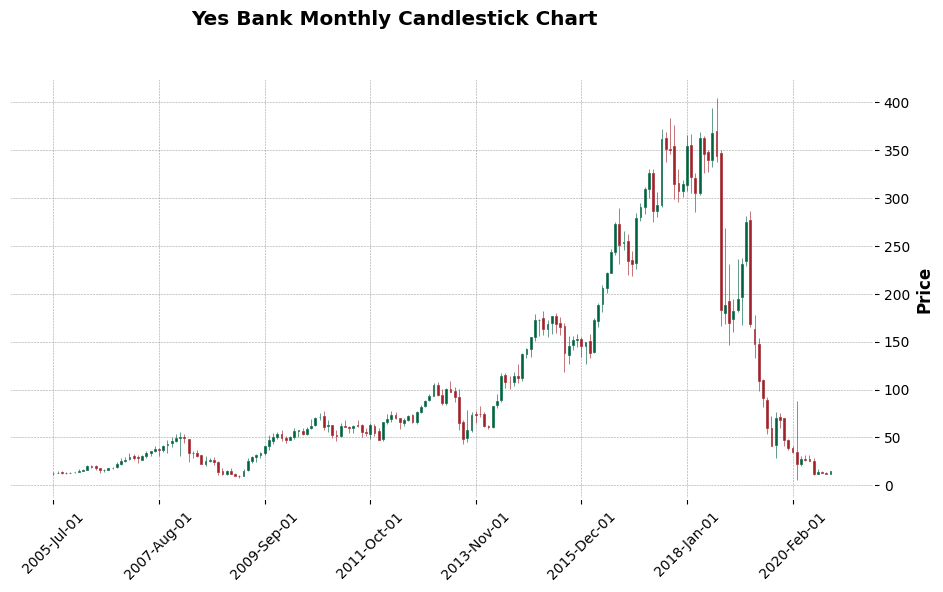

In [20]:
# Candlestick chart
mpf.plot(df, type='candle', style='charles', ylabel='Price',
         title='Yes Bank Monthly Candlestick Chart', figsize=(12, 6))

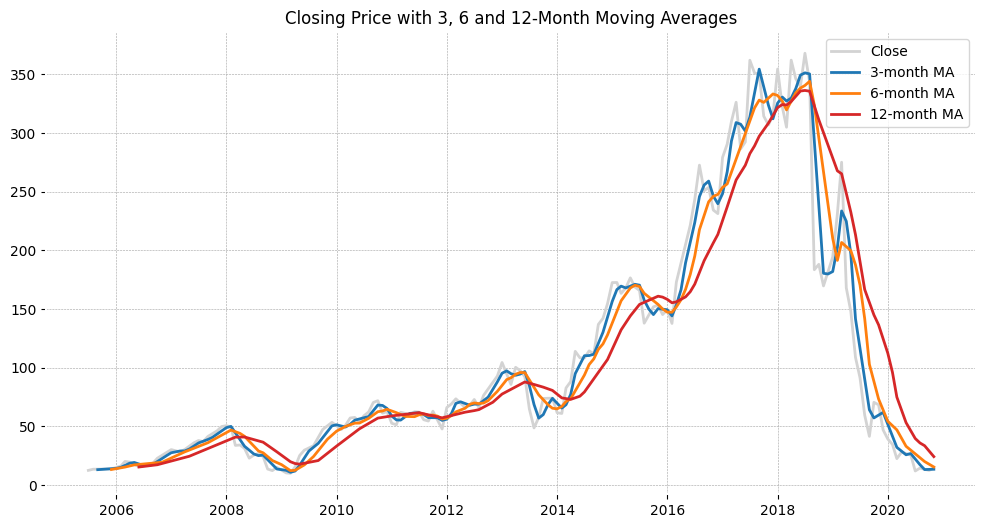

In [21]:
# Moving averages (monthly data, so windows are in months)
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close', color='lightgray')
for window, color in [(3, 'tab:blue'), (6, 'tab:orange'), (12, 'tab:red')]:
    plt.plot(df.index, df['Close'].rolling(window).mean(), label=f'{window}-month MA', color=color)
plt.title('Closing Price with 3, 6 and 12-Month Moving Averages')
plt.legend()
plt.show()

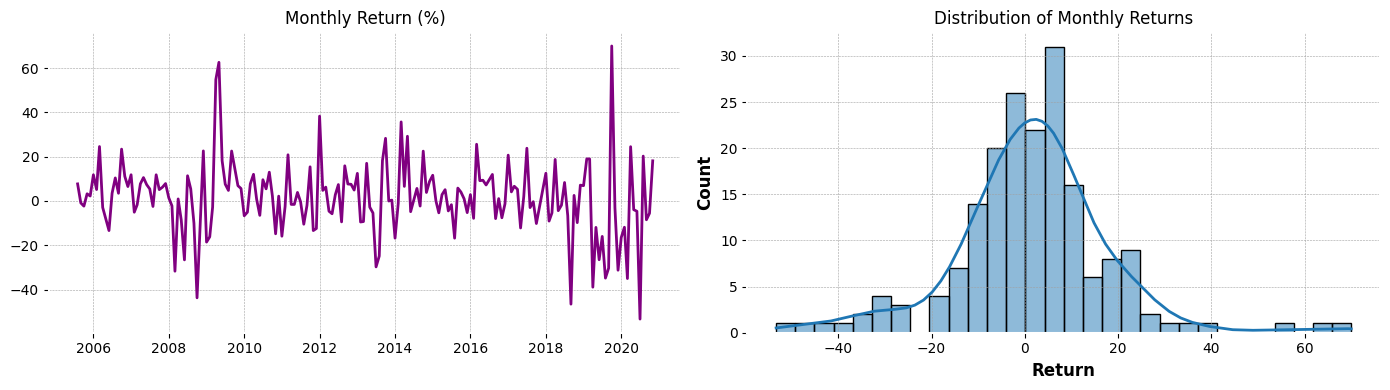

In [22]:
# Monthly returns
df['Return'] = df['Close'].pct_change() * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df.index, df['Return'], color='purple')
axes[0].set_title('Monthly Return (%)')
sns.histplot(df['Return'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Monthly Returns')
plt.tight_layout()
plt.show()

In [23]:
alpha = 0.05

In [24]:
# Test 1: is this month's close related to next month's close?
r, p = stats.pearsonr(df['Close'].iloc[:-1], df['Close'].shift(-1).iloc[:-1])
print(f"Test 1 - Close(t) vs Close(t+1): r = {r:.3f}, p = {p:.4g}")
print("  ->", "Significant correlation" if p < alpha else "No significant correlation")

Test 1 - Close(t) vs Close(t+1): r = 0.978, p = 3.246e-126
  -> Significant correlation


In [25]:
# Test 2: did volatility change after Jan 2018?
before = df.loc[:'2017-12-31', 'Return'].dropna()
after = df.loc['2018-01-01':, 'Return'].dropna()
stat, p = stats.levene(before, after)
print(f"\nTest 2 - Return std before vs after 2018: {before.std():.1f}% vs {after.std():.1f}%, p = {p:.4g}")
print("  ->", "Volatility differs significantly" if p < alpha else "No significant difference")


Test 2 - Return std before vs after 2018: 13.9% vs 23.9%, p = 0.0005713
  -> Volatility differs significantly


In [26]:
# Test 3: did the average monthly return change after Jan 2018?
t, p = stats.ttest_ind(before, after, equal_var=False)
print(f"\nTest 3 - Mean return before vs after 2018: {before.mean():.2f}% vs {after.mean():.2f}%, p = {p:.4g}")
print("  ->", "Mean returns differ significantly" if p < alpha else "No significant difference")


Test 3 - Mean return before vs after 2018: 3.12% vs -5.40%, p = 0.04912
  -> Mean returns differ significantly


In [27]:
model_df = df[['Open', 'High', 'Low', 'Close']].copy()
for lag in (1, 2, 3):
    model_df[f'Close_lag{lag}'] = model_df['Close'].shift(lag)
model_df['MA3'] = model_df['Close'].rolling(3).mean()
model_df['Target'] = model_df['Close'].shift(-1)      # next month's close
model_df = model_df.dropna()

X = model_df.drop(columns='Target')
y = model_df['Target']

split = int(len(model_df) * 0.8)                       # first 80% train, last 20% test
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train:", X_train.index.min().date(), "to", X_train.index.max().date(), f"({len(X_train)} months)")
print("Test :", X_test.index.min().date(), "to", X_test.index.max().date(), f"({len(X_test)} months)")

Train: 2005-10-01 to 2017-09-01 (144 months)
Test : 2017-10-01 to 2020-10-01 (37 months)


In [28]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    direction = np.mean(np.sign(np.asarray(y_pred) - X_test['Close']) == np.sign(y_true - X_test['Close']))
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Direction accuracy': direction}

predictions = {'Baseline (last close)': X_test['Close'].values}

lin = LinearRegression().fit(X_train, y_train)
predictions['Linear Regression'] = lin.predict(X_test)

rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)
predictions['Random Forest'] = rf.predict(X_test)

results = pd.DataFrame([evaluate(n, y_test, p) for n, p in predictions.items()])
results = results.sort_values('RMSE').reset_index(drop=True)
results.round(3)

,Model,RMSE,MAE,R2,Direction accuracy
0,Baseline (last close),38.314,23.357,0.911,0.000
1,Linear Regression,39.840,25.910,0.903,0.378
2,Random Forest,43.457,28.165,0.885,0.568


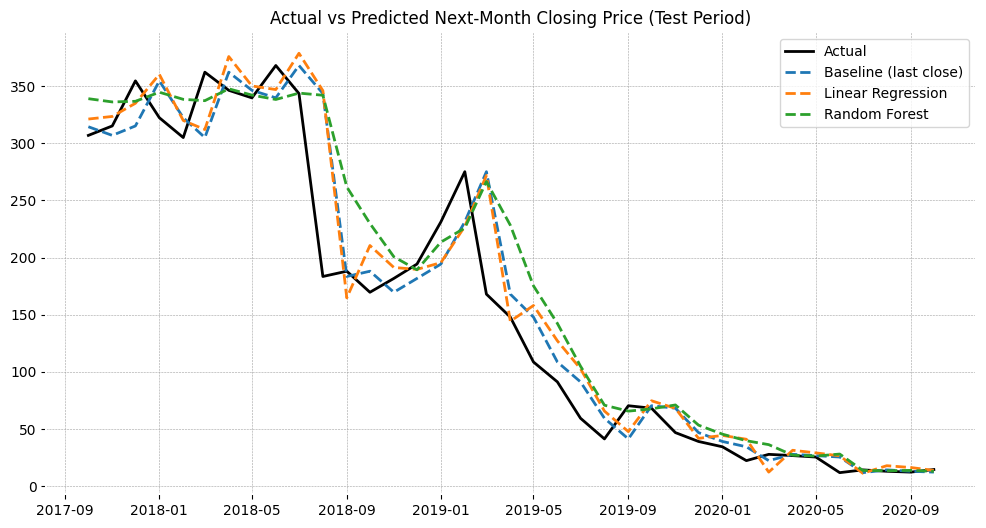

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual', color='black', linewidth=2)
for name, pred in predictions.items():
    plt.plot(y_test.index, pred, label=name, linestyle='--')
plt.title("Actual vs Predicted Next-Month Closing Price (Test Period)")
plt.legend()
plt.show()

In [ ]:
# Pick the best real model on the test period, then refit it on all data
best_name = 'Linear Regression' if (
    results[results['Model'] == 'Linear Regression']['RMSE'].iloc[0]
    <= results[results['Model'] == 'Random Forest']['RMSE'].iloc[0]
) else 'Random Forest'

final_model = (LinearRegression() if best_name == 'Linear Regression'
               else RandomForestRegressor(n_estimators=300, random_state=42)).fit(X, y)
print("Final model:", best_name)

def predict_next_month(open_, high, low, close, lag1, lag2, lag3):
    ma3 = (close + lag1 + lag2) / 3
    row = pd.DataFrame([[open_, high, low, close, lag1, lag2, lag3, ma3]], columns=X.columns)
    return float(final_model.predict(row)[0])

print("\nEnter this month's prices and the closes from the previous 3 months:")
labels = ["Open", "High", "Low", "Close", "Close 1 month ago", "Close 2 months ago", "Close 3 months ago"]
vals = [float(input(f"{label}: ")) for label in labels]
pred = predict_next_month(*vals)
print(f"\nPredicted next-month close: {pred:.2f}  ({(pred - vals[3]) / vals[3] * 100:+.1f}% vs this month's close)")

Final model: Linear Regression

Enter this month's prices and the closes from the previous 3 months:


Open:  65
High:  90
Low:  38
Close:  39
Close 1 month ago:  67
Close 2 months ago:  88
